# 04 · Metric analysis — frozen transferability

Este notebook ejecuta el bracket congelado completo y compara `composition_smiles` con `unit_cell_smiles`. ChemBERTa y MoLFormer se evalúan sin fine-tuning, usando exactamente los mismos registros `gga-static`, folds agrupados por fórmula y regresor Ridge.

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import matplotlib.pyplot as plt
import pandas as pd

def find_repo_root():
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / 'data' / 'results_no_meta.json').exists() and (candidate / 'transferability').exists():
            return candidate
    raise FileNotFoundError('No se encontró la raíz del repositorio')

REPO_ROOT = find_repo_root()
TRANSFERABILITY = REPO_ROOT / 'transferability'
SCRIPTS = TRANSFERABILITY / 'scripts'
ARTIFACTS = REPO_ROOT / 'artifacts'
TABLE = TRANSFERABILITY / 'data' / 'SMILES' / 'composition_smiles.csv'
UNIT_TABLE = TRANSFERABILITY / 'data' / 'unit_cell_SMILES' / 'unit_cell_smiles.csv'
print(f'Repositorio: {REPO_ROOT}')

Repositorio: /Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis


## Configuración de ejecución

Las descargas reutilizan `.cache/`; por tanto, volver a ejecutar el notebook no vuelve a bajar los pesos. La extracción se hace offline después de verificar la caché.

In [2]:
RUN_DOWNLOAD = True
RUN_EMBEDDINGS = True
RUN_EVALUATION = True
DEVICE = 'auto'  # auto, cpu, cuda o mps
PYTHON = REPO_ROOT / '.venv' / 'bin' / 'python'
if not PYTHON.exists():
    PYTHON = Path(sys.executable)
print(f'Python para scripts: {PYTHON}')

def run_script(arguments, tail=1800):
    command = [str(PYTHON), *map(str, arguments)]
    print('$', ' '.join(command))
    completed = subprocess.run(
        command, cwd=REPO_ROOT, text=True, capture_output=True, check=True
    )
    combined = (completed.stdout + '\n' + completed.stderr).strip()
    if combined:
        print(combined[-tail:])

Python para scripts: /Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis/.venv/bin/python


## 1. Verificar o descargar checkpoints

In [3]:
if RUN_DOWNLOAD:
    run_script([SCRIPTS / 'download_hf_models.py'])

$ /Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis/.venv/bin/python /Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis/transferability/scripts/download_hf_models.py


Cached at /Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis/.cache/huggingface/hub/models--seyonec--ChemBERTa-zinc-base-v1/snapshots/761d6a18cf99db371e0b43baf3e2d21b3e865a20
Cached at /Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis/.cache/huggingface/hub/models--ibm-research--MoLFormer-XL-both-10pct/snapshots/361063d0ad524ef77cf39b08469f6be770dc550f
Manifest: /Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis/.cache/huggingface/download_manifest.json


Fetching 7 files: 100%|██████████| 7/7 [00:00<00:00, 3536.94it/s]

Fetching 8 files: 100%|██████████| 8/8 [00:00<00:00, 2333.73it/s]


## 2. Extraer embeddings congelados

Se extraen embeddings tanto para el baseline de composición desconectada como para el grafo `unit_cell_smiles`.

In [4]:
if not TABLE.exists():
    raise FileNotFoundError('Ejecuta primero transferability/toSMILES.ipynb')
if not UNIT_TABLE.exists():
    raise FileNotFoundError('Ejecuta primero transferability/unitCellSMILES.ipynb')
if RUN_EMBEDDINGS:
    run_script([SCRIPTS / 'extract_frozen_embeddings.py', '--device', DEVICE], tail=3500)
    run_script([
        SCRIPTS / 'extract_frozen_embeddings.py',
        '--input', UNIT_TABLE,
        '--smiles-column', 'unit_cell_smiles',
        '--representation-name', 'unit_cell_smiles',
        '--device', DEVICE,
    ], tail=3500)

$ /Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis/.venv/bin/python /Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis/transferability/scripts/extract_frozen_embeddings.py --device auto


Device: mps; records: 480; unique inputs: 80
Loading chemberta: seyonec/ChemBERTa-zinc-base-v1@761d6a18cf99db371e0b43baf3e2d21b3e865a20
{
  "model_alias": "chemberta",
  "repo_id": "seyonec/ChemBERTa-zinc-base-v1",
  "revision": "761d6a18cf99db371e0b43baf3e2d21b3e865a20",
  "input_table": "/Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis/transferability/data/SMILES/composition_smiles.csv",
  "smiles_column": "composition_smiles",
  "representation_name": "composition_smiles",
  "pooling": "last_hidden_state_mean_without_special_tokens",
  "embedding_shape": [
    480,
    768
  ],
  "records": 480,
  "unique_inputs": 80,
  "token_count_min": 22,
  "token_count_max": 23,
  "untruncated_token_count_min": 22,
  "untruncated_token_count_max": 23,
  "model_max_length_used": 512,
  "unique_inputs_truncated": 0,
  "unknown_token_total": 0,
  "unique_inputs_with_unknown_tokens": 0,
  "device": "mps"
}
Loading molformer: ibm-research/MoLFormer-XL-both-10pct@3

Device: mps; records: 480; unique inputs: 240
Loading chemberta: seyonec/ChemBERTa-zinc-base-v1@761d6a18cf99db371e0b43baf3e2d21b3e865a20
{
  "model_alias": "chemberta",
  "repo_id": "seyonec/ChemBERTa-zinc-base-v1",
  "revision": "761d6a18cf99db371e0b43baf3e2d21b3e865a20",
  "input_table": "/Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis/transferability/data/unit_cell_SMILES/unit_cell_smiles.csv",
  "smiles_column": "unit_cell_smiles",
  "representation_name": "unit_cell_smiles",
  "pooling": "last_hidden_state_mean_without_special_tokens",
  "embedding_shape": [
    480,
    768
  ],
  "records": 480,
  "unique_inputs": 240,
  "token_count_min": 54,
  "token_count_max": 219,
  "untruncated_token_count_min": 54,
  "untruncated_token_count_max": 219,
  "model_max_length_used": 512,
  "unique_inputs_truncated": 0,
  "unknown_token_total": 0,
  "unique_inputs_with_unknown_tokens": 0,
  "device": "mps"
}
Loading molformer: ibm-research/MoLFormer-XL-both

## Auditoría de tokenización y embeddings

In [5]:
embedding_audits = []
for path in sorted((ARTIFACTS / 'embeddings').glob('*.audit.json')):
    audit = json.loads(path.read_text())
    embedding_audits.append({
        'modelo': audit['model_alias'],
        'representación': audit['representation_name'],
        'shape': ' × '.join(map(str, audit['embedding_shape'])),
        'inputs únicos': audit['unique_inputs'],
        'tokens mín.': audit['token_count_min'],
        'tokens máx.': audit['token_count_max'],
        'inputs con UNK': audit['unique_inputs_with_unknown_tokens'],
        'device': audit['device'],
    })
pd.DataFrame(embedding_audits).sort_values(['representación', 'modelo']).set_index(
    ['representación', 'modelo']
)

shape  inputs únicos  \
representación                modelo                                
composition_smiles            chemberta  480 × 768             80   
                              molformer  480 × 768             80   
unit_cell_disconnected_smiles chemberta  480 × 768             80   
                              molformer  480 × 768             80   
unit_cell_smiles              chemberta  480 × 768            240   
                              molformer  480 × 768            240   

                                         tokens mín.  tokens máx.  \
representación                modelo                                
composition_smiles            chemberta           22           23   
                              molformer           11           11   
unit_cell_disconnected_smiles chemberta           85           89   
                              molformer           41           41   
unit_cell_smiles              chemberta           54          219   
                              molformer           32          118   

                                         inputs con UNK device  
representación                modelo                            
composition_smiles            chemberta               0    mps  
                              molformer               0    mps  
unit_cell_disconnected_smiles chemberta               0    mps  
                              molformer               0    mps  
unit_cell_smiles              chemberta               0    mps  
                              molformer               0    mps

## 3. Evaluar energía y band gap con el mismo protocolo

In [6]:
ENERGY_RESULT = ARTIFACTS / 'evaluation' / 'frozen_transfer.json'
BANDGAP_RESULT = ARTIFACTS / 'evaluation' / 'frozen_transfer_bandgap.json'
UNIT_ENERGY_RESULT = ARTIFACTS / 'evaluation' / 'unit_cell_smiles_energy_per_atom.json'
UNIT_BANDGAP_RESULT = ARTIFACTS / 'evaluation' / 'unit_cell_smiles_bandgap.json'
UNIT_EMBEDDINGS = [
    ARTIFACTS / 'embeddings' / 'chemberta_unit_cell_smiles.npz',
    ARTIFACTS / 'embeddings' / 'molformer_unit_cell_smiles.npz',
]

if RUN_EVALUATION:
    run_script([
        SCRIPTS / 'evaluate_frozen_transfer.py',
        '--target', 'energy_per_atom',
        '--calculation', 'gga-static',
    ])
    run_script([
        SCRIPTS / 'evaluate_frozen_transfer.py',
        '--target', 'bandgap',
        '--calculation', 'gga-static',
        '--output', BANDGAP_RESULT,
    ])
    for target, output in [
        ('energy_per_atom', UNIT_ENERGY_RESULT),
        ('bandgap', UNIT_BANDGAP_RESULT),
    ]:
        run_script([
            SCRIPTS / 'evaluate_frozen_transfer.py',
            '--table', UNIT_TABLE,
            '--embeddings', *UNIT_EMBEDDINGS,
            '--representation-column', 'unit_cell_smiles',
            '--target', target,
            '--calculation', 'gga-static',
            '--output', output,
        ], tail=3500)

$ /Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis/.venv/bin/python /Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis/transferability/scripts/evaluate_frozen_transfer.py --target energy_per_atom --calculation gga-static


       },
        {
          "fold": 4,
          "mae": 0.5273729134541429,
          "rmse": 0.6628269652254348,
          "r2": 0.5278804424897439
        }
      ]
    }
  },
  "dummy_mean": {
    "mae": 0.7482413528188369,
    "rmse": 0.8539458274833661,
    "r2": -0.03381186776841538
  },
  "representation_collision_floor": {
    "description": "In-sample mean for records sharing the exact representation string; not a predictive baseline. It quantifies target ambiguity caused by representation collisions.",
    "unique_representation_strings": 80,
    "mae": 0.03496988717500004,
    "rmse": 0.049579027571652855,
    "r2": 0.9965152078440969
  },
  "elemental_fraction_ridge": {
    "dimensions": 17,
    "elements": [
      "Ba",
      "Ca",
      "Cd",
      "Cu",
      "Ge",
      "Hf",
      "Mg",
      "Nb",
      "Pb",
      "S",
      "Si",
      "Sn",
      "Sr",
      "Ti",
      "V",
      "Zn",
      "Zr"
    ],
    "overall": {
      "mae": 0.05370259281081984,
      "r

459316
        },
        {
          "fold": 4,
          "mae": 0.5831068190680214,
          "rmse": 0.7379838392160991,
          "r2": -0.7720987474416503
        }
      ]
    }
  },
  "dummy_mean": {
    "mae": 0.5884543185763889,
    "rmse": 0.7160027865799065,
    "r2": -0.01899236144900618
  },
  "representation_collision_floor": {
    "description": "In-sample mean for records sharing the exact representation string; not a predictive baseline. It quantifies target ambiguity caused by representation collisions.",
    "unique_representation_strings": 80,
    "mae": 0.2650958333333333,
    "rmse": 0.39216722967093737,
    "r2": 0.69430797843023
  },
  "elemental_fraction_ridge": {
    "dimensions": 17,
    "elements": [
      "Ba",
      "Ca",
      "Cd",
      "Cu",
      "Ge",
      "Hf",
      "Mg",
      "Nb",
      "Pb",
      "S",
      "Si",
      "Sn",
      "Sr",
      "Ti",
      "V",
      "Zn",
      "Zr"
    ],
    "overall": {
      "mae": 0.42011919050658586,
   

": [
        {
          "fold": 0,
          "mae": 0.5426948721631439,
          "rmse": 0.7613948891211418,
          "r2": 0.12998216305802923
        },
        {
          "fold": 1,
          "mae": 0.547634901860257,
          "rmse": 0.7776025375815484,
          "r2": -0.1548183206501741
        },
        {
          "fold": 2,
          "mae": 0.510974760943035,
          "rmse": 0.6540800296780003,
          "r2": 0.2297599294694772
        },
        {
          "fold": 3,
          "mae": 0.6963742888437036,
          "rmse": 0.9798471604182055,
          "r2": -0.5026816339541456
        },
        {
          "fold": 4,
          "mae": 0.5252113899783826,
          "rmse": 0.6980444674332335,
          "r2": 0.4763780619875819
        }
      ]
    },
    "molformer": {
      "embedding_file": "/Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis/artifacts/embeddings/molformer_unit_cell_smiles.npz",
      "embedding_dimensions": 768,
  


        {
          "fold": 0,
          "mae": 0.6322147707099458,
          "rmse": 0.8650091856666925,
          "r2": -0.15728237155924618
        },
        {
          "fold": 1,
          "mae": 0.4096924056044923,
          "rmse": 0.5343657233207194,
          "r2": 0.22185329616739324
        },
        {
          "fold": 2,
          "mae": 0.6152106304977806,
          "rmse": 0.7866069010240913,
          "r2": 0.042969535249444024
        },
        {
          "fold": 3,
          "mae": 0.6500794565809594,
          "rmse": 0.9422637157016736,
          "r2": -0.9167155608657758
        },
        {
          "fold": 4,
          "mae": 0.5841508644346587,
          "rmse": 0.7838459794584707,
          "r2": -0.9991974343009573
        }
      ]
    },
    "molformer": {
      "embedding_file": "/Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis/artifacts/embeddings/molformer_unit_cell_smiles.npz",
      "embedding_dimensions": 768,


## Comparación global

El baseline de fracciones elementales indica si el Transformer aporta algo más que una codificación composicional transparente. Para atribuir cualquier cambio a la representación, todos los modelos usan las mismas 240 filas y los mismos cinco folds.

In [7]:
def load_result(path):
    return json.loads(path.read_text())

result_sets = {
    ('Energy (eV/atom)', 'Composition disconnected'): load_result(ENERGY_RESULT),
    ('Band gap (eV)', 'Composition disconnected'): load_result(BANDGAP_RESULT),
    ('Energy (eV/atom)', 'Unit-cell graph'): load_result(UNIT_ENERGY_RESULT),
    ('Band gap (eV)', 'Unit-cell graph'): load_result(UNIT_BANDGAP_RESULT),
}

rows = []
collision_rows = []
for (target, representation), result in result_sets.items():
    for model, values in result['models'].items():
        rows.append({
            'target': target,
            'representación': representation,
            'modelo': model,
            **values['overall'],
        })
    collision_rows.append({
        'target': target,
        'representación': representation,
        **result['representation_collision_floor'],
    })

# Los controles no dependen del SMILES y se muestran una sola vez por target.
for target, result in [
    ('Energy (eV/atom)', result_sets[('Energy (eV/atom)', 'Composition disconnected')]),
    ('Band gap (eV)', result_sets[('Band gap (eV)', 'Composition disconnected')]),
]:
    rows.extend([{
        'target': target, 'representación': 'Control', 'modelo': 'Dummy mean',
        **result['dummy_mean'],
    }, {
        'target': target, 'representación': 'Control', 'modelo': 'Element fractions',
        **result['elemental_fraction_ridge']['overall'],
    }])

metrics = pd.DataFrame(rows)
metrics['método'] = metrics['modelo'] + ' · ' + metrics['representación']
baseline_mae = (metrics[metrics['representación'] == 'Composition disconnected']
                .set_index(['target', 'modelo'])['mae'])
metrics['Δ MAE vs composition'] = metrics.apply(
    lambda row: row['mae'] - baseline_mae.get((row['target'], row['modelo']), row['mae']),
    axis=1,
)
(metrics[['target', 'representación', 'modelo', 'mae', 'rmse', 'r2', 'Δ MAE vs composition']]
 .sort_values(['target', 'modelo', 'representación']).round(4))

,target,representación,modelo,mae,rmse,r2,Δ MAE vs composition
10,Band gap (eV),Control,Dummy mean,0.5885,0.7160,-0.0190,0.0000
11,Band gap (eV),Control,Element fractions,0.4201,0.5350,0.4310,0.0000
2,Band gap (eV),Composition disconnected,chemberta,0.5087,0.6559,0.1449,0.0000
6,Band gap (eV),Unit-cell graph,chemberta,0.5783,0.7943,-0.2541,0.0696
3,Band gap (eV),Composition disconnected,molformer,0.6725,0.8446,-0.4178,0.0000
7,Band gap (eV),Unit-cell graph,molformer,0.7737,1.0758,-1.3003,0.1012
8,Energy (eV/atom),Control,Dummy mean,0.7482,0.8539,-0.0338,0.0000
9,Energy (eV/atom),Control,Element fractions,0.0537,0.0734,0.9924,0.0000
0,Energy (eV/atom),Composition disconnected,chemberta,0.1508,0.2669,0.8990,0.0000
4,Energy (eV/atom),Unit-cell graph,chemberta,0.5646,0.7822,0.1325,0.4138


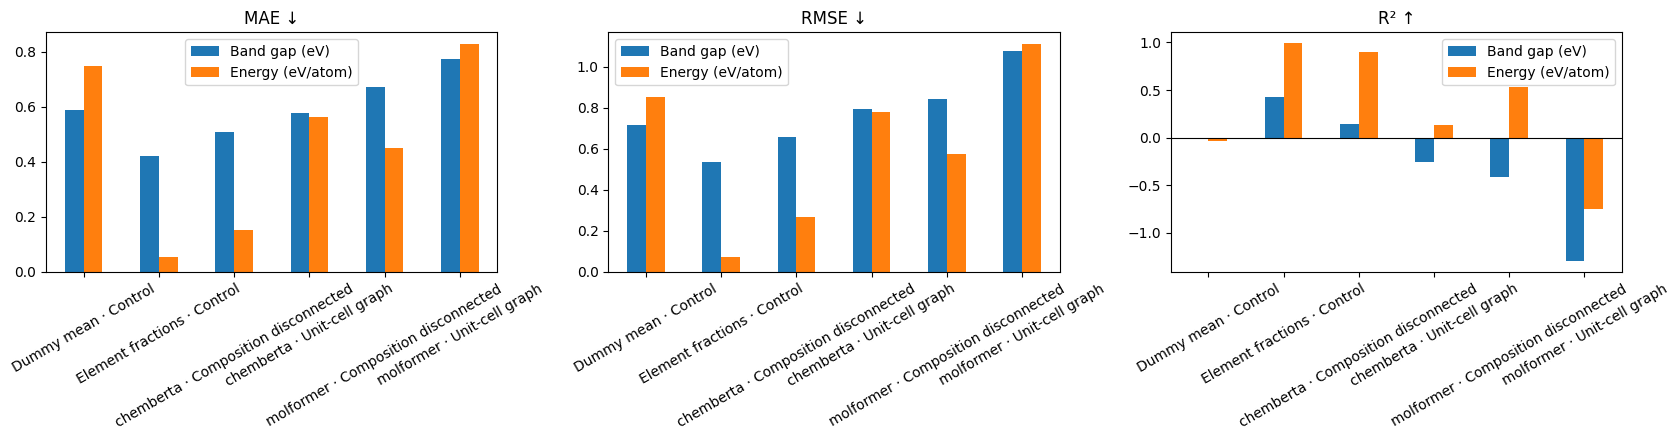

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for axis, metric, title in zip(axes, ['mae', 'rmse', 'r2'], ['MAE ↓', 'RMSE ↓', 'R² ↑']):
    metrics.pivot(index='método', columns='target', values=metric).plot.bar(ax=axis)
    axis.set(title=title, xlabel='')
    axis.tick_params(axis='x', rotation=30)
    axis.legend(title='')
    if metric == 'r2':
        axis.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

## Colisiones de representación

La tabla usa la media conocida de cada string y **no** es un modelo predictivo. Cuantifica la ambigüedad que aparece cuando distintas estructuras comparten exactamente la misma entrada. El valor cero de `unit_cell_smiles` sólo confirma que cada estructura tiene un string distinto; no implica capacidad predictiva.

In [9]:
pd.DataFrame(collision_rows)[
    ['target', 'representación', 'unique_representation_strings', 'mae', 'rmse', 'r2']
].sort_values(['target', 'representación']).round(4)

,target,representación,unique_representation_strings,mae,rmse,r2
1,Band gap (eV),Composition disconnected,80,0.2651,0.3922,0.6943
3,Band gap (eV),Unit-cell graph,240,0.0000,0.0000,1.0000
0,Energy (eV/atom),Composition disconnected,80,0.0350,0.0496,0.9965
2,Energy (eV/atom),Unit-cell graph,240,0.0000,0.0000,1.0000


## Lectura recomendada

- Superar `Dummy mean` demuestra señal útil frente a una predicción constante.
- Superar `Element fractions` sería evidencia más fuerte de información transferida por el preentrenamiento molecular.
- `Δ MAE vs composition < 0` significa que el grafo de celda mejora frente al baseline desconectado para el mismo modelo y target.
- Que `unit_cell_smiles` distinga los polimorfos elimina colisiones, pero no garantiza que el lenguaje del preentrenamiento molecular interprete correctamente esos grafos heurísticos.
- Superar `Element fractions` sería evidencia más fuerte de información transferida por el preentrenamiento molecular.
- Estos resultados corresponden a un smoke test con un Ridge fijo; la estimación final de tesis debe añadir selección anidada de hiperparámetros, múltiples seeds e intervalos de confianza.